In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, f1_score

In [3]:
df = pd.read_csv("data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()
print("Shape:",df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Shape: (891, 12)


In [5]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [6]:
df.drop("PassengerId",axis=1,inplace=True)
df.drop("Name",axis=1,inplace=True)
df.drop("Ticket",axis=1,inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [7]:
df.groupby("Sex")["Age"].mean()


Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

<Axes: ylabel='Age'>

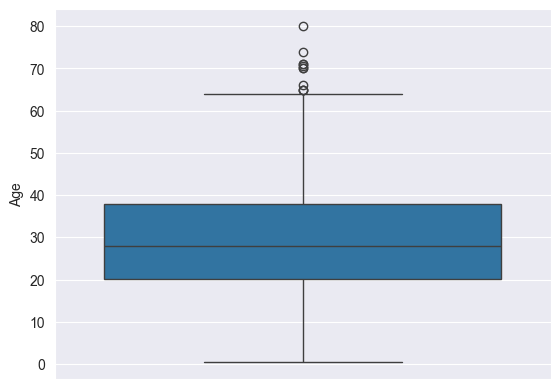

In [8]:
sns.boxplot(df["Age"])

In [9]:
print("Survived:",df.query('Survived == 1').shape)
print("NO Survived:",df.query('Survived == 0').shape)

Survived: (342, 9)
NO Survived: (549, 9)


In [10]:
miss_data = df.isnull().sum()
miss_data[miss_data > 0]

Age         177
Cabin       687
Embarked      2
dtype: int64

In [11]:
df["Age"] =  df["Age"].fillna(df['Age'].median())
df["Embarked"] = df["Embarked"].fillna(df['Embarked'].mode()[0])

In [12]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      0
dtype: int64

In [13]:
df['Has_cabin']= df['Cabin'] == 1
df['Has_cabin'] = df['Has_cabin'].astype(int)
df.drop("Cabin", axis=1,inplace=True)

In [14]:
df = pd.get_dummies(df, columns=["Sex"],dtype="int")
df = pd.get_dummies(df, columns=["Embarked"], dtype=int)
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Has_cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,0,1,0,0,1
1,1,1,38.0,1,0,71.2833,0,1,0,1,0,0
2,1,3,26.0,0,0,7.9250,0,1,0,0,0,1
3,1,1,35.0,1,0,53.1000,0,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,0,0,1,0,0,1
887,1,1,19.0,0,0,30.0000,0,1,0,0,0,1
888,0,3,28.0,1,2,23.4500,0,1,0,0,0,1
889,1,1,26.0,0,0,30.0000,0,0,1,1,0,0


In [15]:
X = df.drop("Survived",axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=5,random_state=42)

model.fit(X_train, y_train)

y_predict = model.predict(X_test)

f1_score(y_test, y_predict)

0.7272727272727273

In [16]:
df_test = pd.read_csv("data/test.csv")
df_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [17]:
passenger_ids = df_test["PassengerId"]

df_test["Age"] = df_test["Age"].fillna(df["Age"].median())
df_test["Fare"] = df_test["Fare"].fillna(df["Fare"].median())
df_test["Has_cabin"] = df_test["Cabin"].notnull().astype(int)

df_test = pd.get_dummies(df_test, columns=["Sex", "Embarked"], dtype=int)

cols_to_drop = ["PassengerId", "Name", "Ticket", "Cabin"]
X_test_final = df_test.drop(columns=cols_to_drop)

predictions = model.predict(X_test_final)

submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": predictions
})

submission.to_csv("data/submission_dt.csv", index=False)

In [18]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
final_predictions = rf_model.predict(X_test_final)

submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": final_predictions
})


submission.to_csv("data/submission_rf.csv", index=False)